# Multilayer math

A practical walk-through of the supra-graph API: the supra-adjacency,
the Laplacian, random-walk / diffusion operators, layer-aware
descriptors, and a coupling-strength sweep.

The fixture is a tiny two-layer graph so every matrix prints cleanly.


In [1]:
import warnings
from annnet import AnnNet

G = AnnNet(directed=False)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # One aspect 't' with two layers t1 and t2.
    G.layers.set_aspects(['t'], {'t': ['t1', 't2']})

    # Same vertices A, B in both layers (4 supra-nodes total).
    G.add_vertices(['A', 'B'], layer={'t': 't1'})
    G.add_vertices(['A', 'B'], layer={'t': 't2'})

    # Intra-layer edges
    G.add_edges(('A', ('t1',)), ('B', ('t1',)), edge_id='e_t1', weight=1.0)
    G.add_edges(('A', ('t2',)), ('B', ('t2',)), edge_id='e_t2', weight=1.0)

    # Diagonal couplings: A in t1 <-> A in t2, B in t1 <-> B in t2.
    n_coup = G.layers.add_layer_coupling_pairs([(('t1',), ('t2',))])

print('layers added couplings:', n_coup)
print('supra-node count nv  :', G.nv)

layers added couplings: 2
supra-node count nv  : 2


## Supra-adjacency

`G.layers.supra_adjacency()` is the full symmetric (for undirected
input) supra-adjacency matrix over the supra-nodes.


In [2]:
import numpy as np

A = G.layers.supra_adjacency()
print('A:')
print(A.toarray())
print('symmetric?', np.allclose((A - A.T).toarray(), 0))

A:
[[0. 1. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [0. 1. 1. 0.]]
symmetric? True


## Block decomposition

`supra_adjacency = intra + inter + coupling`. Each builder returns the
matrix restricted to one edge kind.


In [3]:
A_intra = G.layers.build_intra_block().toarray()
A_inter = G.layers.build_inter_block().toarray()
A_coup = G.layers.build_coupling_block().toarray()

print('intra:')
print(A_intra)
print('coupling:')
print(A_coup)
print('intra + inter + coupling == A?', np.allclose(A_intra + A_inter + A_coup, A.toarray()))

intra:
[[0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]]
coupling:
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]
intra + inter + coupling == A? True


## Laplacian

Combinatorial (`L = D - A`) and normalized (`L = I - D^{-1/2} A D^{-1/2}`).


In [4]:
L_comb = G.layers.supra_laplacian(kind='comb').toarray()
print('combinatorial L:')
print(L_comb)

L_norm = G.layers.supra_laplacian(kind='norm').toarray()
print('\nnormalized L:')
print(L_norm)

combinatorial L:
[[ 2. -1. -1.  0.]
 [-1.  2.  0. -1.]
 [-1.  0.  2. -1.]
 [ 0. -1. -1.  2.]]

normalized L:
[[ 1.  -0.5 -0.5  0. ]
 [-0.5  1.   0.  -0.5]
 [-0.5  0.   1.  -0.5]
 [ 0.  -0.5 -0.5  1. ]]


In [5]:
# Algebraic connectivity (lambda_2) and Fiedler vector
lam2, fiedler = G.layers.algebraic_connectivity()
print('lambda_2 =', lam2)
print('Fiedler  =', fiedler)

lambda_2 = 1.9999999999999998
Fiedler  = [ 0.69847778 -0.11013078  0.11013078 -0.69847778]


## Random-walk transition matrix

`P = D^{-1} A` is row-stochastic.


In [6]:
P = G.layers.transition_matrix().toarray()
print('P:')
print(P)
print('row sums:', P.sum(axis=1))

P:
[[0.  0.5 0.5 0. ]
 [0.5 0.  0.  0.5]
 [0.5 0.  0.  0.5]
 [0.  0.5 0.5 0. ]]
row sums: [1. 1. 1. 1.]


In [7]:
# One step of a random walk starting from supra-node 0
p0 = np.zeros(P.shape[0])
p0[0] = 1.0
p1 = G.layers.random_walk_step(p0)
print('p0:', p0)
print('p1:', p1)
print('mass preserved?', np.isclose(p1.sum(), 1.0))

p0: [1. 0. 0. 0.]
p1: [0.  0.5 0.5 0. ]
mass preserved? True


## Diffusion step

`x_next = x - tau * L @ x` (explicit-Euler step on the combinatorial
Laplacian).


In [8]:
x = np.zeros(G.layers.supra_adjacency().shape[0])
x[0] = 1.0
for _ in range(5):
    x = G.layers.diffusion_step(x, tau=0.1)
print('x after 5 steps:', x)

x after 5 steps: [0.43328 0.23056 0.23056 0.1056 ]


## Layer-aware descriptors


In [9]:
pc = G.layers.participation_coefficient()
vers = G.layers.versatility()
print('participation coefficient:', pc)
print('versatility:               ', vers)

participation coefficient: {'A': 0.5, 'B': 0.5}
versatility:                {'A': 1.0, 'B': 1.0}


## Coupling sweep

Vary the coupling strength `omega` and watch the algebraic connectivity
respond. A common pattern: a phase-like transition when coupling
becomes strong enough to fuse the layers.


In [10]:
scales = np.linspace(0.0, 3.0, 13)
lam2s = G.layers.sweep_coupling_regime(scales.tolist(), metric='algebraic_connectivity')

for w, l in zip(scales, lam2s, strict=False):
    print(f'  omega={w:>4.2f}   lambda_2={l:.4f}')

  omega=0.00   lambda_2=0.0000
  omega=0.25   lambda_2=0.5000
  omega=0.50   lambda_2=1.0000
  omega=0.75   lambda_2=1.5000
  omega=1.00   lambda_2=2.0000
  omega=1.25   lambda_2=2.0000
  omega=1.50   lambda_2=2.0000
  omega=1.75   lambda_2=2.0000
  omega=2.00   lambda_2=2.0000
  omega=2.25   lambda_2=2.0000
  omega=2.50   lambda_2=2.0000
  omega=2.75   lambda_2=2.0000
  omega=3.00   lambda_2=2.0000


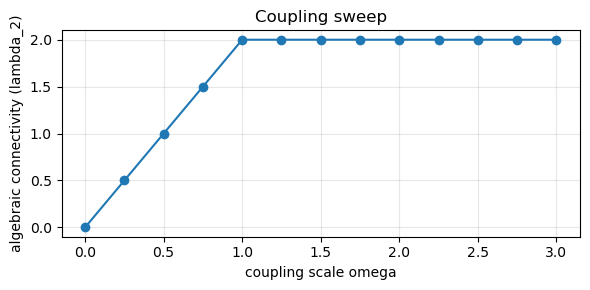

In [11]:
# Quick plot
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6, 3))
    plt.plot(scales, lam2s, marker='o')
    plt.xlabel('coupling scale omega')
    plt.ylabel('algebraic connectivity (lambda_2)')
    plt.title('Coupling sweep')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except ImportError:
    pass

## Tensor view and flatten-unflatten

`adjacency_tensor_view` exposes the supra-adjacency in an
index-as-tensor form `(u, layer_a, v, layer_b) -> w`. You can flatten
back to a supra matrix and round-trip.


In [12]:
view = G.layers.adjacency_tensor_view()
print('view keys:', list(view))
print('ui:', view['ui'][:6])
print('w :', view['w'][:6])

A_back = G.layers.flatten_to_supra(view)
print('flatten matches supra_adjacency?', np.allclose(A_back.toarray(), A.toarray()))

view keys: ['vertices', 'layers', 'vertex_to_i', 'layer_to_i', 'ui', 'ai', 'vi', 'bi', 'w']
ui: [0 1 0 1 1 1]
w : [1. 1. 1. 1. 1. 1.]
flatten matches supra_adjacency? True
